$$
\bigstar\;\diamond\;\bigstar\quad\boxed{\sigma_{\omega}\sigma}\quad\bigstar\;\diamond\;\bigstar
$$

# 图 1.4

## 理论

不存在一套适用于所有问题的最优试验设计方案。实际上，最优试验设计会随研究目标与响应曲面（输入输出关系）类型的变化而改变。图 1.4 展示了若干基于一维函数的示例。举例而言，若目标是近似拟合响应曲面：当响应曲面起伏较大时，采用均匀填充样本空间的设计方案效果较好（图 1.4 左上子图）；而当函数曲线平滑时，在边界附近布置更多样本点的设计方案更为合适（右上子图）。倘若目标是求取函数最大值，则应在全局最大值附近布置更多设计点（左下子图）。与之相对，若研究目标为不确定性传递（$X$ 不确定，探究 $Y=f(X)$ 的不确定性是怎么受 $X$ 传递的），设计点的布置方式需要贴合输入量的分布特征（右下子图，图中曲线代表输入量的概率密度）。

## 实践

创建画布宽 20 英寸、高 20 英寸，将画布分为 2x2。在 c(0,1) 上创建等距的 301 个点作为图像组成点的横坐标，令其为 x。作左上角子图：设粗糙函数为

$$
y=\frac{\sin(10\pi x)}{1+64(x-0.5)^2}
$$

则求解 x 对应的函数值，令其为 y。绘制 x-y 的图像，其中类型为 l，坐标轴不显示，x、y 轴空白，线宽为 3，y 轴的显示范围为 c(min(y)-.05,max(y))，标题为 “粗略逼近一个粗糙函数”，大小为 4。令 n=15，依据均匀设计公式

$$
D=\left\{\frac{i-0.5}{n}\right\}_{i=1}^{n}
$$

取 1:n 上的等距 n 个点，令其为 D。在图像上叠加 D 的图像，其中 D 的纵坐标为 min(y)-.05 为常数，故与 D 使用 cbind() 函数组成 2 列矩阵来补全维度，点的类型为 16，大小为 4，颜色为 blue。

作右上角子图：设光滑函数为

$$y=\frac{1}{1+64(x-0.5)^2}
$$

则求解 x 对应的函数值，令其为 y。绘制 x-y 的图像，其中类型为 l，坐标轴不显示，x、y 轴空白，线宽为 3，y 轴的显示范围为 c(min(y)-.05,max(y))，标题为 “粗略逼近一个光滑函数”，大小为 4。为了让取点应向两边聚集，使用逆变换采样法，先依据均匀设计公式

$$
D=\left\{\frac{i-0.5}{n}\right\}_{i=1}^{n}
$$

取 1:n 上的等距 n 个点，再借助分布函数 $F_{Beta(0.5,0.5)}(x)$ 的逆函数，代入计算，得出的点令其为 D，这样得到的点即向两边聚集。在图像上叠加 D 的图像，其中 D 的纵坐标为 min(y)-.05 为常数，故与 D 使用 cbind() 函数组成 2 列矩阵来补全维度，点的类型为 16，大小为 4，颜色为 blue。

作左下角子图：设被优化的函数为

$$
y=\frac23f_{Beta(2,10)}(x)+\frac13f_{Beta(10,2)}(x)
$$

则求解 x 对应的函数值，令其为 y。绘制 x-y 的图像，其中类型为 l，坐标轴不显示，x、y 轴空白，线宽为 3，y 轴的显示范围为 c(min(y)-.05,max(y))，标题为 “优化采样”，大小为 4。令 n1=n*2/3，n2=n/3。观察函数，其借助 $f_{Beta(2,10)}(x)$ 与 $f_{Beta(10,2)}(x)$ 生成。首先为了在全区间均匀设计，先依据均匀设计公式

$$
D=\left\{\frac{i-0.5}{n}\right\}_{i=1}^{n}
$$

取 1:n2 上的等距 n2 个点，令其为 D0，接着为了让取点应向最大值聚集，使用逆变换采样法，先依据均匀设计公式

$$
D=\left\{\frac{i-0.5}{n}\right\}_{i=1}^{n}
$$

取 1:n1 上的等距 n1 个点，再借助分布函数 $F_{Beta(2,10)}(x)$ 的逆函数，代入计算，得出的点与 D0 拼接和称为 D，这样得到的点即向最大值聚集。在图像上叠加 D 的图像，其中 D 的纵坐标为 min(y)-.05 为常数，故与 D 使用 cbind() 函数组成 2 列矩阵来补全维度，点的类型为 16，大小为 4，颜色为 blue。

作右下角子图：设被探究不确定性的函数仍为

$$
y=\frac23f_{Beta(2,10)}(x)+\frac13f_{Beta(2,10)}(x)
$$

则求解 x 对应的函数值，令其为 y。绘制 x-y 的图像，其中类型为 l，坐标轴不显示，x、y 轴空白，线宽为 3，y 轴的显示范围为 c(min(y)-.05,max(y))，标题为 “不确定性传播”，大小为 4。设置种子为 1，先在 $Beta(2,10)$ 上大量寻找契合分布的点：依据权重，在 $Beta(2,10)$ 上随机抽取 1000\*n1 个点，在 $Beta(10,2)$ 上随机抽取 1000\*n2 个点，拼成初始点集 x。导入 support 包，使用 sp() 函数选取支撑点，即最能代表这些 x 的点，其中选取 n 个点，对行操作，被选取的点集矩阵为 cbind(x)，其中的 cbind() 函数正是用来把向量 x 转为矩阵的。取出选取结果列表中的 sp 列，正是最终选取的代表点向量，令其为 D，这样得到的点最能代表函数的走势。在图像上叠加 D 的图像，其中 D 的纵坐标为 min(y)-.05 为常数，故与 D 使用 cbind() 函数组成 2 列矩阵来补全维度，点的类型为 16，大小为 4，颜色为 blue。将画布还原回 1x1。

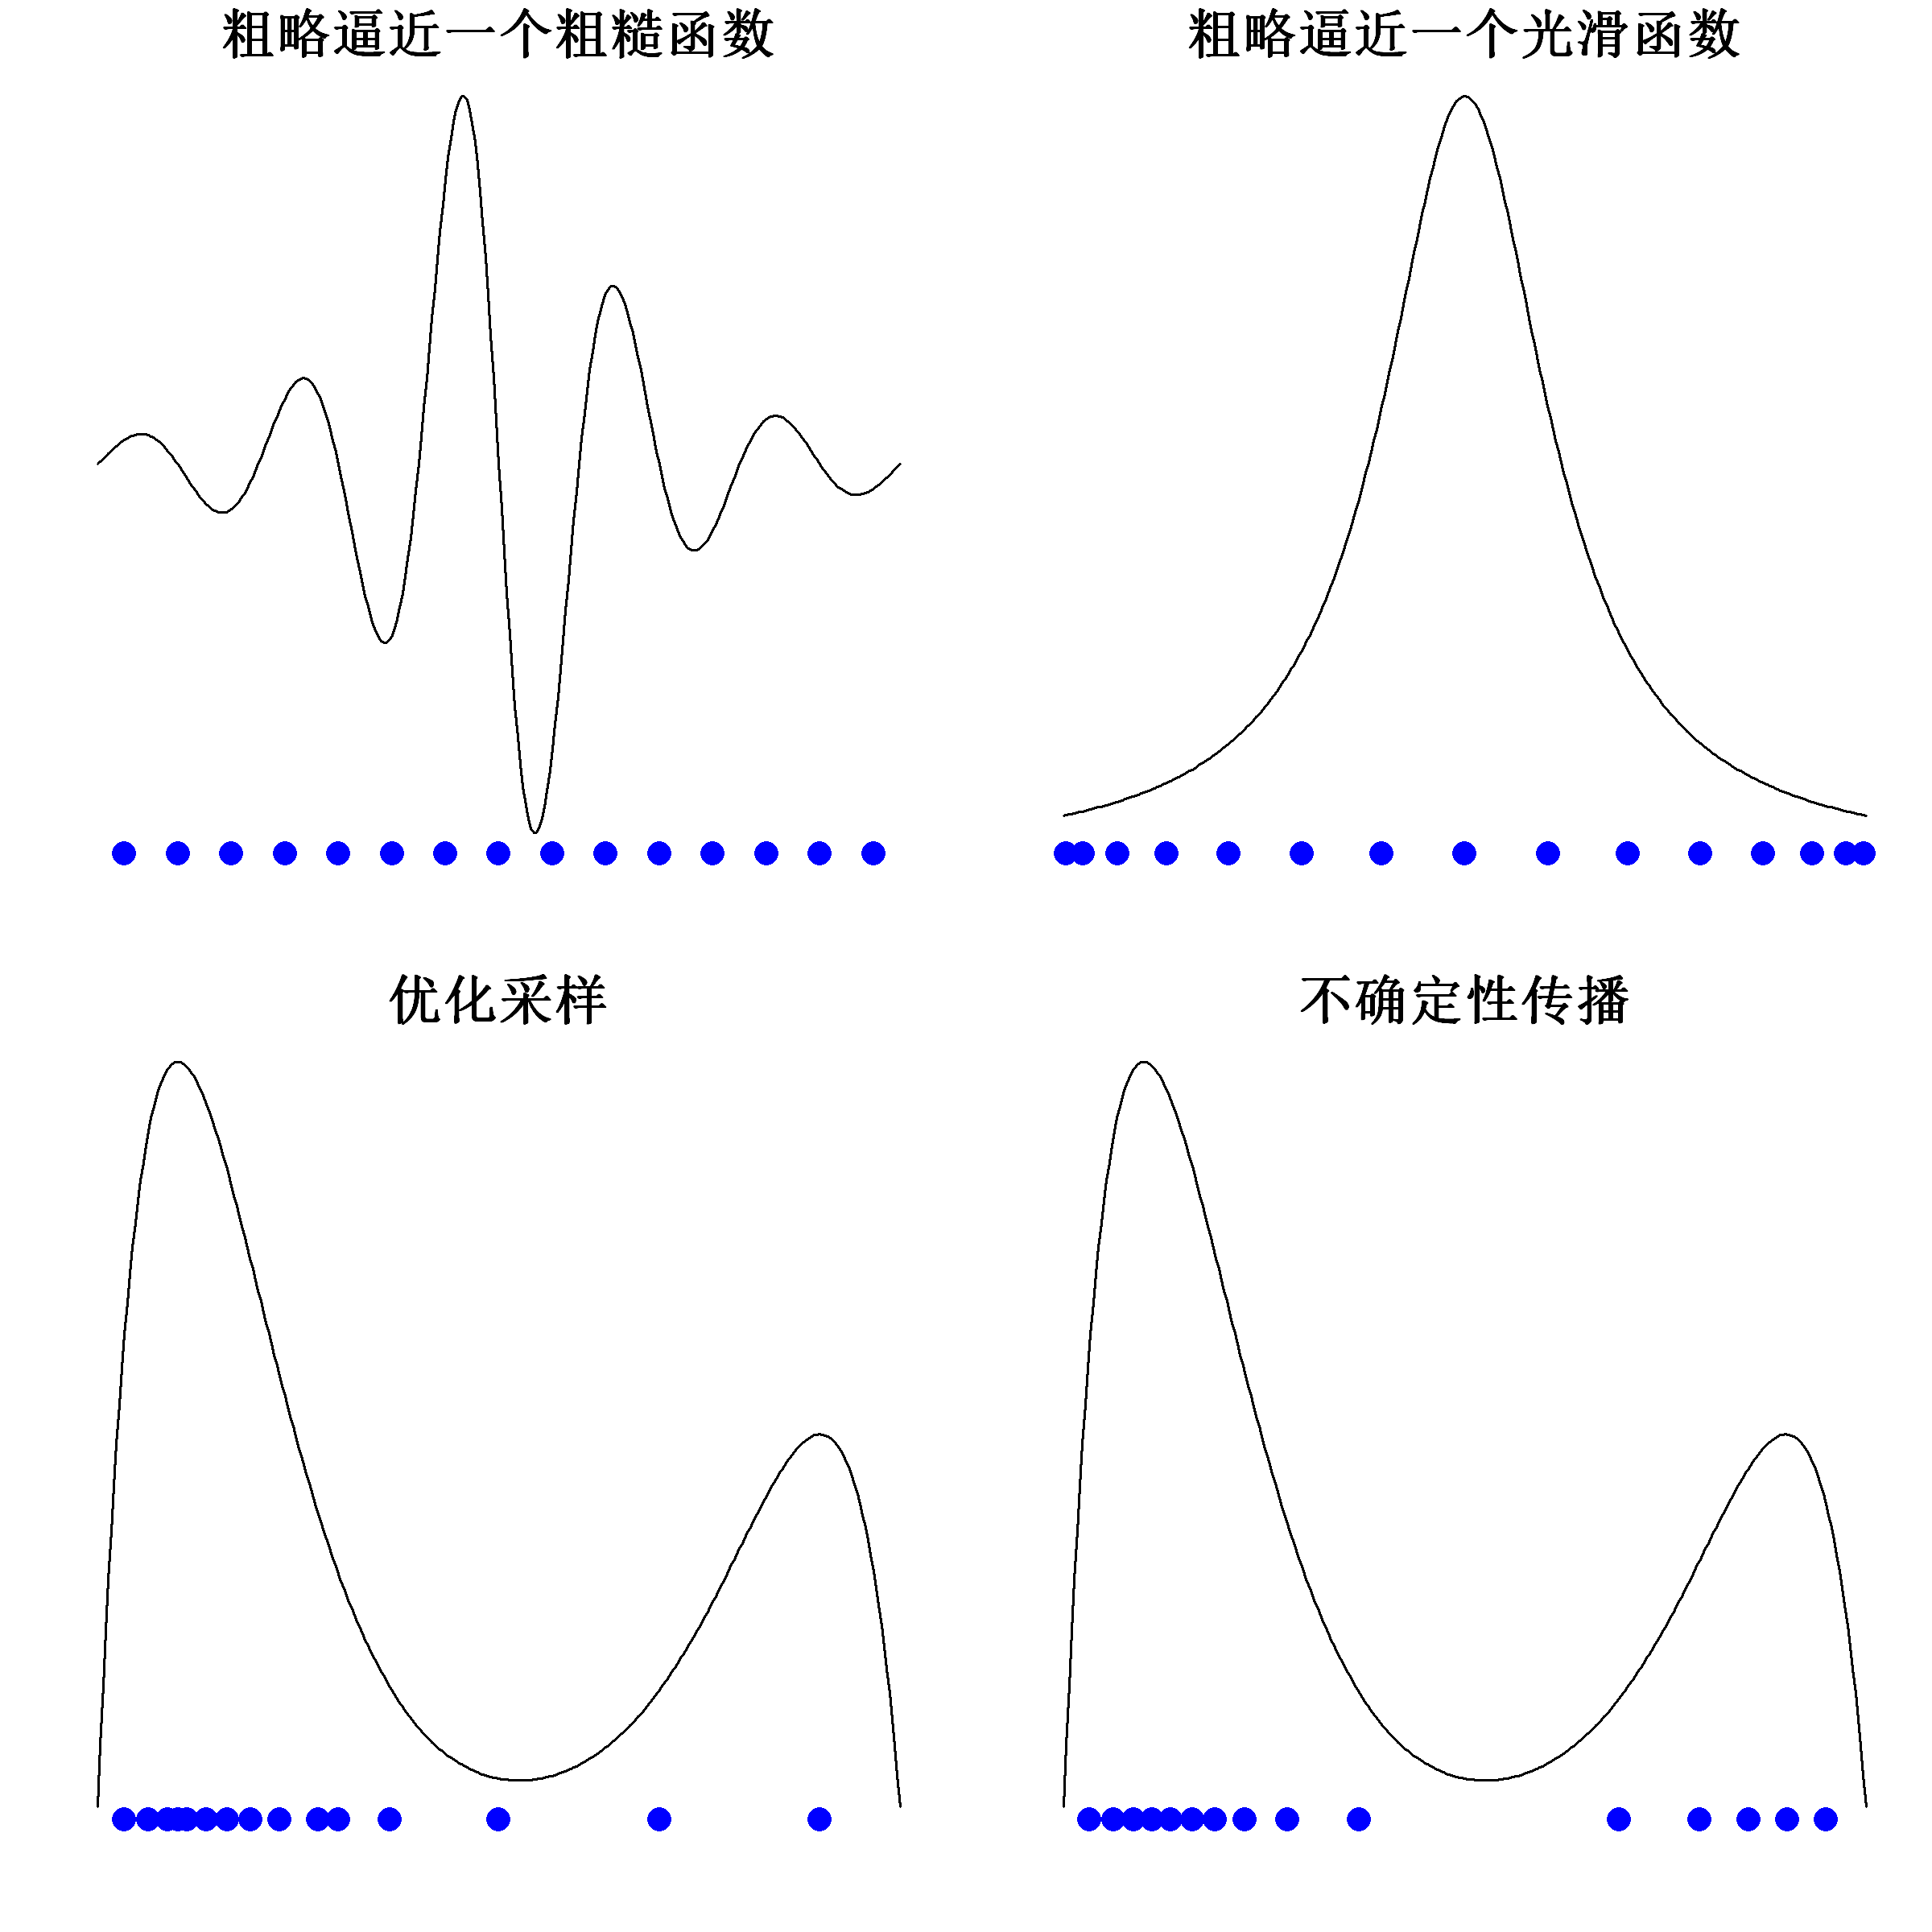

In [5]:
# 图 1.4

options(repr.plot.width=20,repr.plot.height=20)
par(mfrow=c(2,2))
x=seq(0,1,length=301)
y=sin(10*pi*x)/(1+64*(x-.5)^2)
plot(x,y,type="l",axes=FALSE,xlab="",ylab="",lwd=3,ylim=c(min(y)-.05,max(y)),main="粗略逼近一个粗糙函数",cex.main=4)
n=15
D=((1:n)-.5)/n
points(cbind(D,min(y)-.05),pch=16,cex=4,col="blue")

y=1/(1+64*(x-.5)^2)
plot(x,y,type="l",axes=FALSE,xlab="",ylab="",lwd=3,ylim=c(min(y)-.05,max(y)),main="粗略逼近一个光滑函数",cex.main=4)
D=qbeta(((1:n)-.5)/n,.5,.5)
points(cbind(D,min(y)-.05),pch=16,cex=4,col="blue")

y=2/3*dbeta(x,2,10)+1/3*dbeta(x,10,2)
plot(x,y,type="l",axes=FALSE,xlab="",ylab="",lwd=3,ylim=c(min(y)-.05,max(y)),main="优化采样",cex.main=4)
n1=n*2/3;n2=n/3
D0=((1:n2)-.5)/n2
D=c(D0,qbeta(((1:n1)-.5)/n1,2,10))
points(cbind(D,min(y)-.05),pch=16,cex=4,col="blue")

y=2/3*dbeta(x,2,10)+1/3*dbeta(x,10,2)
plot(x,y,type="l",axes=FALSE,xlab="",ylab="",lwd=3,ylim=c(min(y)-.05,max(y)),main="不确定性传播",cex.main=4)
set.seed(1)
x=c(rbeta(1000*n1,2,10),rbeta(1000*n2,10,2))
library(support)
D=sp(n,1,dist.samp=cbind(x))$sp
points(cbind(D,min(y)-.05),pch=16,cex=4,col="blue")
par(mfrow=c(1,1))

$$
\bigstar\;\diamond\;\bigstar\quad\boxed{\sigma_{\omega}\sigma}\quad\bigstar\;\diamond\;\bigstar
$$